# Imports

In [3]:
from pathlib import Path
import math
import os
import sys
from random import random

import torch
from torchvision.datasets import VisionDataset, MNIST, EMNIST
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision.transforms import GaussianBlur

from utils.checkpoint import load_checkpoint
from utils.data import get_dataloaders, get_datasets

PROJECT_ROOT = Path(os.path.abspath(os.pardir))
sys.path.append(str(PROJECT_ROOT))

from models.lenet import Net as LeNet
from config import Config, load_config

In [4]:
from config import get_dataset

mnist_config = load_config(str(PROJECT_ROOT / "configs" / "mnist" / "lenet_baseline.yaml"))
emnist_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters" / "lenet_baseline.yaml"))
emnist10_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters-10" / "lenet.yaml"))
emnist18_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters-18" / "lenet.yaml"))


In [5]:
from torch.utils.data import DataLoader
from typing import Callable

def make_loader(
    dataset_cls: Callable[..., VisionDataset],
    *,
    dataset_kwargs: dict | None=None,
    dataset_transforms: Callable[..., VisionDataset] | None=None,
    batch_size: int = 128,
):
    dataset_kwargs = dataset_kwargs or {}

    _, test_dataset = get_datasets(
        root=str(PROJECT_ROOT / "data"),
        dataset=dataset_cls,
        download=True,
        normalize=True,
        dataset_kwargs=dataset_kwargs
    )

    test_dataset = dataset_transforms(test_dataset) if dataset_transforms else test_dataset

    return DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=1,
    )

# Preliminary functions

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 42
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# Load evaluations from `.npz`

In [7]:
SEEDS = [21, 42, 63]

_d = np.load(f"npz/mnist_vs_emnist-letters_comparison_seed_{SEEDS[0]}.npz", allow_pickle=True)
T: int = int(_d["mc_samples"])
kernel_sizes: list[int] = _d["kernel_sizes"].tolist()
del _d

def to_tensors(evals: dict) -> dict:
    return {ks: tuple(torch.from_numpy(array) for array in values) for ks, values in evals.items()}


In [8]:
from config import build_transform

mnist_labels = torch.cat([y for _, y in make_loader(MNIST)]).cpu()
emnist_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                     dataset_kwargs=emnist_config.data.kwargs)]).cpu()
emnist10_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                       dataset_kwargs=emnist10_config.data.kwargs,
                                                       dataset_transforms=build_transform(emnist10_config.data.dataset_transform))]).cpu()
emnist18_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                       dataset_kwargs=emnist18_config.data.kwargs,
                                                       dataset_transforms=build_transform(emnist18_config.data.dataset_transform))]).cpu()


# Корреляция между предсказанной уверенностью и неопределенностью

In [9]:
import numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss


def calculate_correlations(probs: torch.Tensor, total_uncs: torch.Tensor, labels: torch.Tensor) -> tuple[float, float]:
    """
    Calculate Pearson correlations between predicted and true confidences and total uncertainties.
    Args:
        probs: Tensor of shape [B, C] with predicted probabilities for each class
        total_uncs: Tensor of shape [B] with total uncertainties
        labels: Tensor of shape [B] with true labels

    Returns:
        tuple[float, float]: Pearson correlations for predicted and true confidences

    """
    pred_conf = probs[torch.arange(len(probs)), probs.argmax(dim=1)].cpu().numpy() # [B]
    true_conf = probs[torch.arange(len(labels)), labels].cpu().numpy() # [B]
    total_uncs = total_uncs.cpu().numpy() # [B]
    return np.corrcoef(pred_conf, total_uncs)[0, 1], np.corrcoef(true_conf, total_uncs)[0, 1]

# Each model maps to its `.npz` key and the matching test labels.
MODELS: dict[str, tuple[str, torch.Tensor]] = {
    "MNIST": ("mnist_evals", mnist_labels),
    "EMNIST-10": ("emnist-10_evals", emnist10_labels),
    "EMNIST-18": ("emnist-18_evals", emnist18_labels),
    "EMNIST-26": ("emnist_evals", emnist_labels),
}

def correlations_for(evals: dict, labels: torch.Tensor) -> tuple[np.ndarray, np.ndarray]:
    """Per-kernel (predicted, true) confidence correlations for one model and one seed."""
    preds, trues = [], []
    for ks in kernel_sizes:
        probs, total_uncs = evals[ks][0], evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1)
        n = min(len(probs), len(labels))
        pred, true = calculate_correlations(probs[:n], total_uncs[:n], labels[:n])
        preds.append(pred)
        trues.append(true)
    return np.array(preds), np.array(trues)

def auroc_for(evals: dict, labels: torch.Tensor) -> np.ndarray:
    """Per-kernel AUROC of total uncertainty for detecting misclassifications."""
    scores = []
    for ks in kernel_sizes:
        probs, total_uncs = evals[ks][0], evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1)
        n = min(len(probs), len(labels))
        wrong = (probs[:n].argmax(dim=1) != labels[:n]).cpu().numpy().astype(int)
        scores.append(roc_auc_score(wrong, total_uncs[:n].cpu().numpy()))
    return np.array(scores)

# Aggregate per-seed statistics over seeds. Each entry ends up shaped [len(SEEDS), len(kernel_sizes)].
results: dict[str, dict[str, np.ndarray]] = {name: {"pred": [], "true": [], "auroc": []} for name in MODELS}
for seed in SEEDS:
    _d = np.load(f"npz/mnist_vs_emnist-letters_comparison_seed_{seed}.npz", allow_pickle=True)
    for name, (key, labels) in MODELS.items():
        evals = to_tensors(_d[key].item())
        preds, trues = correlations_for(evals, labels)
        results[name]["pred"].append(preds)
        results[name]["true"].append(trues)
        results[name]["auroc"].append(auroc_for(evals, labels))
    del _d

for r in results.values():
    r["pred"] = np.stack(r["pred"])    # [S, K]
    r["true"] = np.stack(r["true"])    # [S, K]
    r["auroc"] = np.stack(r["auroc"])  # [S, K]


In [10]:
from sklearn.metrics import log_loss, brier_score_loss

_d = np.load(f"npz/mnist_vs_emnist-letters_comparison_seed_{42}.npz", allow_pickle=True)
evals = to_tensors(_d["mnist_evals"].item())
del _d

print(brier_score_loss(mnist_labels, evals[9][0].cpu().numpy(), labels=np.arange(10), sample_weight=None, pos_label=1))
print(log_loss(mnist_labels, evals[9][0].cpu().numpy(), labels=np.arange(10), sample_weight=None))


0.06190727129860222
0.14117700528090132


# Левый subplot — pred_conf

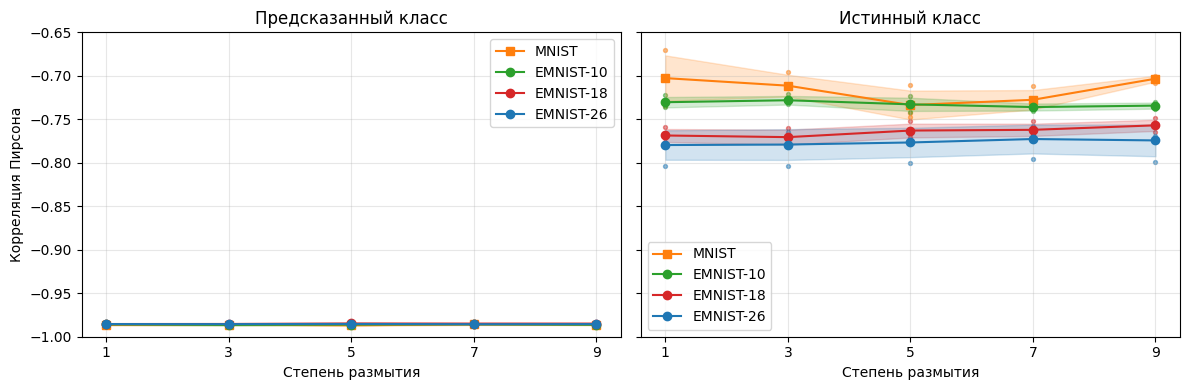

In [22]:
colors = {'MNIST': 'C1', 'EMNIST-10': 'C2', 'EMNIST-18': 'C3', 'EMNIST-26': 'C0'}
markers = {'MNIST': 's', 'EMNIST-10': 'o', 'EMNIST-18': 'o', 'EMNIST-26': 'o'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for name, r in results.items():
    mean, std = r["pred"].mean(axis=0), r["pred"].std(axis=0)
    axes[0].set_title("Предсказанный класс")
    axes[0].set_ylabel("Корреляция Пирсона")
    axes[0].plot(kernel_sizes, mean, marker=markers[name], color=colors[name], label=name)
    axes[0].fill_between(kernel_sizes, mean - std, mean + std, color=colors[name], alpha=0.2)
    axes[0].scatter(np.tile(kernel_sizes, len(SEEDS)), r["pred"].ravel(),
               color=colors[name], s=8, alpha=0.5, zorder=0)


for name, r in results.items():
    mean, std = r["true"].mean(axis=0), r["true"].std(axis=0)
    axes[1].set_title("Истинный класс")
    axes[1].plot(kernel_sizes, mean, marker=markers[name], color=colors[name], label=name)
    axes[1].fill_between(kernel_sizes, mean - std, mean + std, color=colors[name], alpha=0.2)
    axes[1].scatter(np.tile(kernel_sizes, len(SEEDS)), r["true"].ravel(),
               color=colors[name], s=8, alpha=0.5, zorder=0)

# ax.set_title('Predicted class')
for i in range(2):
    axes[i].set_xticks(kernel_sizes)
    axes[i].set_xlabel("Степень размытия")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(bottom=-1, top=-0.65)
    axes[i].legend()
plt.tight_layout()
plt.show()



# Правый subplot — true_conf


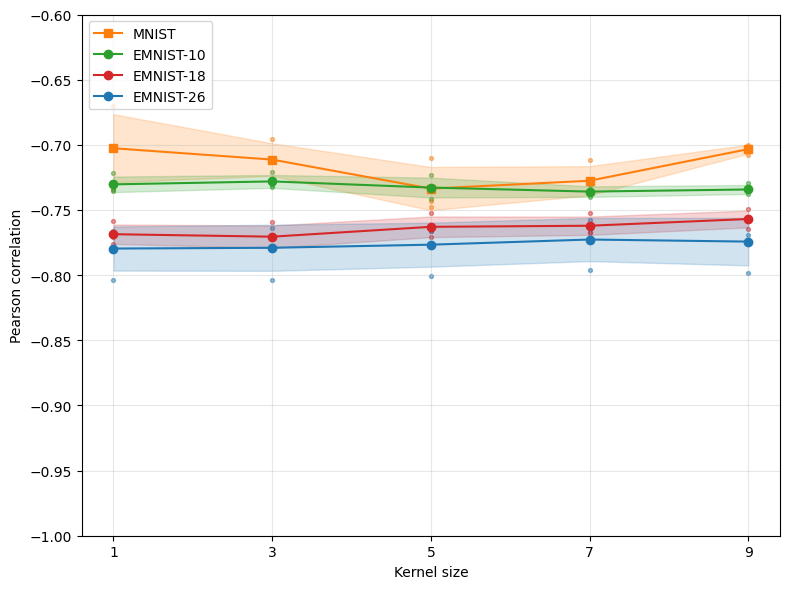

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

for name, r in results.items():
    mean, std = r["true"].mean(axis=0), r["true"].std(axis=0)
    ax.plot(kernel_sizes, mean, marker=markers[name], color=colors[name], label=name)
    ax.fill_between(kernel_sizes, mean - std, mean + std, color=colors[name], alpha=0.2)
    ax.scatter(np.tile(kernel_sizes, len(SEEDS)), r["true"].ravel(),
               color=colors[name], s=8, alpha=0.5, zorder=0)

# ax.set_title('True class')
ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Pearson correlation")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-1, top=-0.6)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [10]:
for name, r in results.items():
    mean, std = r["true"].mean(axis=0), r["true"].std(axis=0)
    print(f"{name:>11}: " + "  ".join(f"{m:+.3f}±{s:.3f}" for m, s in zip(mean, std)))


      MNIST: -0.703±0.026  -0.711±0.013  -0.734±0.017  -0.728±0.011  -0.703±0.003
  EMNIST-10: -0.730±0.006  -0.728±0.005  -0.733±0.008  -0.736±0.004  -0.734±0.003
  EMNIST-18: -0.769±0.007  -0.771±0.009  -0.763±0.008  -0.762±0.007  -0.757±0.006
  EMNIST-26: -0.780±0.017  -0.779±0.018  -0.777±0.017  -0.773±0.017  -0.774±0.018


# AUROC: неопределенность как детектор ошибок


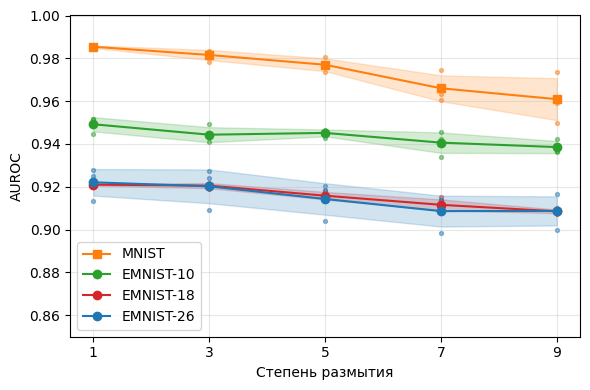

In [23]:
fig, ax = plt.subplots(figsize=(6, 4), sharey=True)

for name, r in results.items():
    mean, std = r["auroc"].mean(axis=0), r["auroc"].std(axis=0)
    ax.plot(kernel_sizes, mean, marker=markers[name], color=colors[name], label=name)
    ax.fill_between(kernel_sizes, mean - std, mean + std, color=colors[name], alpha=0.2)
    ax.scatter(np.tile(kernel_sizes, len(SEEDS)), r["auroc"].ravel(),
               color=colors[name], s=8, alpha=0.5, zorder=0)

ax.set_xticks(kernel_sizes)
ax.set_xlabel("Степень размытия")
ax.set_ylabel("AUROC")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0.85, top=1.0)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


In [12]:
for name, r in results.items():
    mean, std = r["auroc"].mean(axis=0), r["auroc"].std(axis=0)
    print(f"{name:>11}: " + "  ".join(f"{m:.3f}±{s:.3f}" for m, s in zip(mean, std)))


      MNIST: 0.985±0.001  0.982±0.002  0.977±0.003  0.966±0.006  0.961±0.010
  EMNIST-10: 0.949±0.003  0.944±0.004  0.945±0.002  0.941±0.005  0.939±0.003
  EMNIST-18: 0.921±0.000  0.921±0.001  0.916±0.002  0.912±0.003  0.909±0.001
  EMNIST-26: 0.922±0.006  0.920±0.008  0.914±0.007  0.909±0.007  0.909±0.007


# Сравнение метрик: Pearson и AUROC


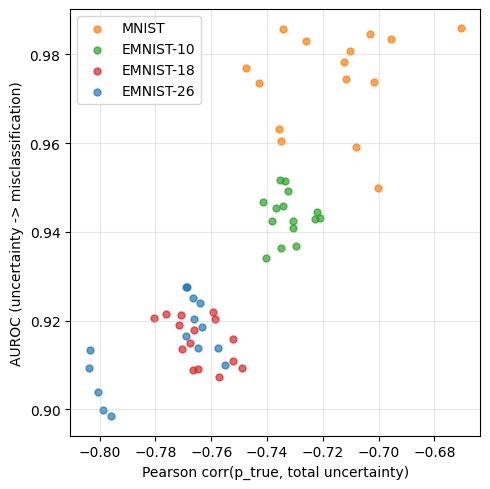

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

for name, r in results.items():
    ax.scatter(r["true"].ravel(), r["auroc"].ravel(), color=colors[name], label=name, alpha=0.7, s=25)

ax.set_xlabel("Pearson corr(p_true, total uncertainty)")
ax.set_ylabel("AUROC (uncertainty -> misclassification)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
